# Создание предсказательной модели убыточности ресторана
У вас имеется 2 файла с данными - `train.csv` и `test.csv` для тренировки и тестирования моделей соответственно.

В файле `train.csv` есть поле `'Profitability'`, а в `test.csv` нет.

Вам необходимо предсказать рентабельность(`'Profitability'`) для данных в файле test.csv - (`Low`/`Medium`/`High`).

При помощи этой модели рестораны смогут регулировать меню на основе данных и принимать более взвешенные решения.

Ваш файл должен иметь размерность 195 строк на 2 столбца с полями `'id'` и `'Profitability'`.

Минимальное значение метрики Accuracy: `0.75`

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml

import warnings
warnings.filterwarnings('ignore')

Загрузим датасеты `train.csv` и `test.csv` и посмотрим на них

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train.head()

,RestaurantID,MenuCategory,MenuItem,Ingredients,Price,Profitability,id
0,R001,Appetizers,Spinach Artichoke Dip,"['Tomatoes', 'Basil', 'Garlic', 'Olive Oil']",11.12,Medium,1
1,R003,Desserts,New York Cheesecake,"['Chocolate', 'Butter', 'Sugar', 'Eggs']",18.66,High,2
2,R003,Main Course,Chicken Alfredo,"['Chicken', 'Fettuccine', 'Alfredo Sauce', 'Pa...",29.55,High,3
3,R002,Main Course,Grilled Steak,"['Chicken', 'Fettuccine', 'Alfredo Sauce', 'Pa...",17.73,Medium,4
4,R001,Appetizers,Stuffed Mushrooms,"['Tomatoes', 'Basil', 'Garlic', 'Olive Oil']",12.28,High,5


In [4]:
train.describe(include='all')

,RestaurantID,MenuCategory,MenuItem,Ingredients,Price,Profitability,id
count,778,778,778,778,778.000000,778,778.000000
unique,3,4,16,4,NaN,3,NaN
top,R001,Desserts,New York Cheesecake,"['Chocolate', 'Butter', 'Sugar', 'Eggs']",NaN,Medium,NaN
freq,264,211,57,211,NaN,384,NaN
mean,NaN,NaN,NaN,NaN,13.187095,NaN,481.345758
std,NaN,NaN,NaN,NaN,7.400259,NaN,289.908182
min,NaN,NaN,NaN,NaN,2.010000,NaN,1.000000
25%,NaN,NaN,NaN,NaN,8.295000,NaN,229.250000
50%,NaN,NaN,NaN,NaN,12.825000,NaN,470.500000
75%,NaN,NaN,NaN,NaN,17.947500,NaN,727.750000


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   RestaurantID   778 non-null    str    
 1   MenuCategory   778 non-null    str    
 2   MenuItem       778 non-null    str    
 3   Ingredients    778 non-null    str    
 4   Price          778 non-null    float64
 5   Profitability  778 non-null    str    
 6   id             778 non-null    int64  
dtypes: float64(1), int64(1), str(5)
memory usage: 42.7 KB


Пустых значений нет.

У `RestaurantID` 3 уникальных значения.

У `MenuCategory` 4 уникальных значения.

У `MenuItem` 16 уникальных значений.

У `Profitability` 3 уникальных значения, по которым и будем делать классификацию.

`Ingredients` - это список ингридиентов, которые лучше разложить на бинарные признаки с помощью **One-Hot Encoding**.

В общем, я бы подумал, что можно и для всех перечисленных категорий такое сделать

In [6]:
all_ingredients = train.Ingredients.str.replace(' ', '').str.replace('[', '').str.replace(']', '').str.replace("'", '').str.split(',').explode().unique()

In [7]:
all_ingredients

<StringArray>
[    'Tomatoes',        'Basil',       'Garlic',     'OliveOil',
    'Chocolate',       'Butter',        'Sugar',         'Eggs',
      'Chicken',   'Fettuccine', 'AlfredoSauce',     'Parmesan',
 'confidential']
Length: 13, dtype: str

Теперь напишем функцию, которая создаёт колонки со всеми категориальными признаками из одного столбца

In [8]:
def categorial(dataset, column):
    columns = dataset[column].str.replace(' ', '').str.replace('[', '').str.replace(']', '').str.replace("'", '').str.split(',').explode().unique()
    
    for item in columns:
        dataset[f'{column}_{item}'] = dataset[column].apply(lambda x: 1 if item in str(x).split(',') else 0)

    dataset.drop(column, axis=1, inplace=True)

Применим функцию у нужным полям

In [9]:
categorial(train, 'RestaurantID')
categorial(train, 'MenuCategory')
categorial(train, 'MenuItem')
categorial(train, 'Ingredients')
train.drop('id', axis=1, inplace=True)

train.head()

,Price,Profitability,RestaurantID_R001,RestaurantID_R003,RestaurantID_R002,MenuCategory_Appetizers,MenuCategory_Desserts,MenuCategory_MainCourse,MenuCategory_Beverages,MenuItem_SpinachArtichokeDip,...,Ingredients_OliveOil,Ingredients_Chocolate,Ingredients_Butter,Ingredients_Sugar,Ingredients_Eggs,Ingredients_Chicken,Ingredients_Fettuccine,Ingredients_AlfredoSauce,Ingredients_Parmesan,Ingredients_confidential
0,11.12,Medium,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,18.66,High,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,29.55,High,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17.73,Medium,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12.28,High,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Для столбца `Profitability` используем обычный маппинг. Напишем функцию маппинга (и сразу анмапинга) значений по словарю

In [10]:
prtofitability_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

def mapping(dataset, column, mapping_dict):
    dataset[column] = dataset[column].map(mapping_dict)

def unmapping(dataset, column, mapping_dict):
    dataset[column] = dataset[column].map({v: k for k, v in mapping_dict.items()})

In [11]:
mapping(train, 'Profitability', prtofitability_mapping)
# Отсортируем колонки в одном порядке по алфавиту
train = train.sort_index(axis=1)

train.head()

,Ingredients_AlfredoSauce,Ingredients_Basil,Ingredients_Butter,Ingredients_Chicken,Ingredients_Chocolate,Ingredients_Eggs,Ingredients_Fettuccine,Ingredients_Garlic,Ingredients_OliveOil,Ingredients_Parmesan,...,MenuItem_Soda,MenuItem_SpinachArtichokeDip,MenuItem_StuffedMushrooms,MenuItem_Tiramisu,MenuItem_VegetableStir-Fry,Price,Profitability,RestaurantID_R001,RestaurantID_R002,RestaurantID_R003
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,11.12,1,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,18.66,2,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,29.55,2,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,17.73,1,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,12.28,2,1,0,0


Теперь обучим модель

In [12]:
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.linear_model import LogisticRegression

# Разбиваем датасет на X_train и y_train
X_train = train.copy()
X_train.drop('Profitability', axis=1, inplace=True)

y_train = train['Profitability']

# Обучаем модель OneVsRestClassifier
ovr = OneVsRestClassifier(LogisticRegression())
ovr.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegression()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](3,)","[0,1,2]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegression(), LogisticRegression(), LogisticRegression()]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['Ingredients_AlfredoSauce','Ingredients_Basil','Ingredients_Butter',..., 'RestaurantID_R001','RestaurantID_R002','RestaurantID_R003']"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,37


Преобразуем тестовый датасет

In [13]:
categorial(test, 'RestaurantID')
categorial(test, 'MenuCategory')
categorial(test, 'MenuItem')
categorial(test, 'Ingredients')

test = test.sort_index(axis=1)
test.head()

,Ingredients_AlfredoSauce,Ingredients_Basil,Ingredients_Butter,Ingredients_Chicken,Ingredients_Chocolate,Ingredients_Eggs,Ingredients_Fettuccine,Ingredients_Garlic,Ingredients_OliveOil,Ingredients_Parmesan,...,MenuItem_Soda,MenuItem_SpinachArtichokeDip,MenuItem_StuffedMushrooms,MenuItem_Tiramisu,MenuItem_VegetableStir-Fry,Price,RestaurantID_R001,RestaurantID_R002,RestaurantID_R003,id
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2.39,1,0,0,519
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,25.25,0,0,1,543
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3.72,1,0,0,85
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,10.66,0,0,1,782
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2.96,1,0,0,877


Теперь применяем обученную модель на тестовых данных

In [14]:
X_test = test.copy()
X_test.drop('id', axis=1, inplace=True)

y_pred = ovr.predict(X_test)

Соединим обратно результаты

In [15]:
result = pd.DataFrame(y_pred, columns=['Profitability'])
result = pd.concat([test['id'], result.astype('int64')], axis=1)
unmapping(result, 'Profitability', prtofitability_mapping)
result

,id,Profitability
0,519,Medium
1,543,High
2,85,Medium
3,782,Medium
4,877,Medium
...,...,...
190,744,Medium
191,45,Medium
192,557,High
193,301,Medium


In [16]:
result.to_csv('result.csv', index=False)

## Просто проверить себя

Не часть решения, а проверка для себя. Модель выше обучена на всех 778 строках
и метрику посчитать не на чем, потому что тест закрыт.

Ниже тот же код на удержанной четверти train, чтобы посмотреть на
classification report своими глазами. На `result.csv` это никак не влияет.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# `train` выше уже разобран на бинарные колонки и без колонки `id`,
# поэтому для разбиения читаем файл заново
train_raw = pd.read_csv("train.csv")

tr, va = train_test_split(train_raw, test_size=0.25, random_state=42,
                         stratify=train_raw["Profitability"])

tr = tr.copy()
va = va.copy()

for df in (tr, va):
    for col in ["RestaurantID", "MenuCategory", "MenuItem", "Ingredients"]:
        categorial(df, col)
    df.drop("id", axis=1, inplace=True)

# набор бинарных колонок зависит от уникальных значений в срезе,
# поэтому явно приводим validation к тем же колонкам, что и train
tr = tr.sort_index(axis=1)
va = va.sort_index(axis=1)

y_tr = tr["Profitability"].map(prtofitability_mapping)
y_va = va["Profitability"].map(prtofitability_mapping)

X_tr = tr.drop("Profitability", axis=1)
X_va = va.reindex(columns=X_tr.columns, fill_value=0)

print("признаков:", X_tr.shape[1])
print("train:", X_tr.shape, " valid:", X_va.shape)

признаков: 37
train: (583, 37)  valid: (195, 37)


In [18]:
ovr_val = OneVsRestClassifier(LogisticRegression(max_iter=2000))
ovr_val.fit(X_tr, y_tr)
pred_val = ovr_val.predict(X_va)

print(classification_report(y_va, pred_val,
                            target_names=["Low", "Medium", "High"],
                            digits=4, zero_division=0))
print(f"accuracy   = {(pred_val == y_va).mean():.4f}")
print(f"macro F1   = {f1_score(y_va, pred_val, average='macro'):.4f}")
print("\nconfusion matrix")
print(confusion_matrix(y_va, pred_val))

              precision    recall  f1-score   support

         Low     0.0000    0.0000    0.0000        21
      Medium     0.7712    0.9479    0.8505        96
        High     0.8961    0.8846    0.8903        78

    accuracy                         0.8205       195
   macro avg     0.5558    0.6108    0.5803       195
weighted avg     0.7381    0.8205    0.7748       195

accuracy   = 0.8205
macro F1   = 0.5803

confusion matrix
[[ 0 18  3]
 [ 0 91  5]
 [ 0  9 69]]


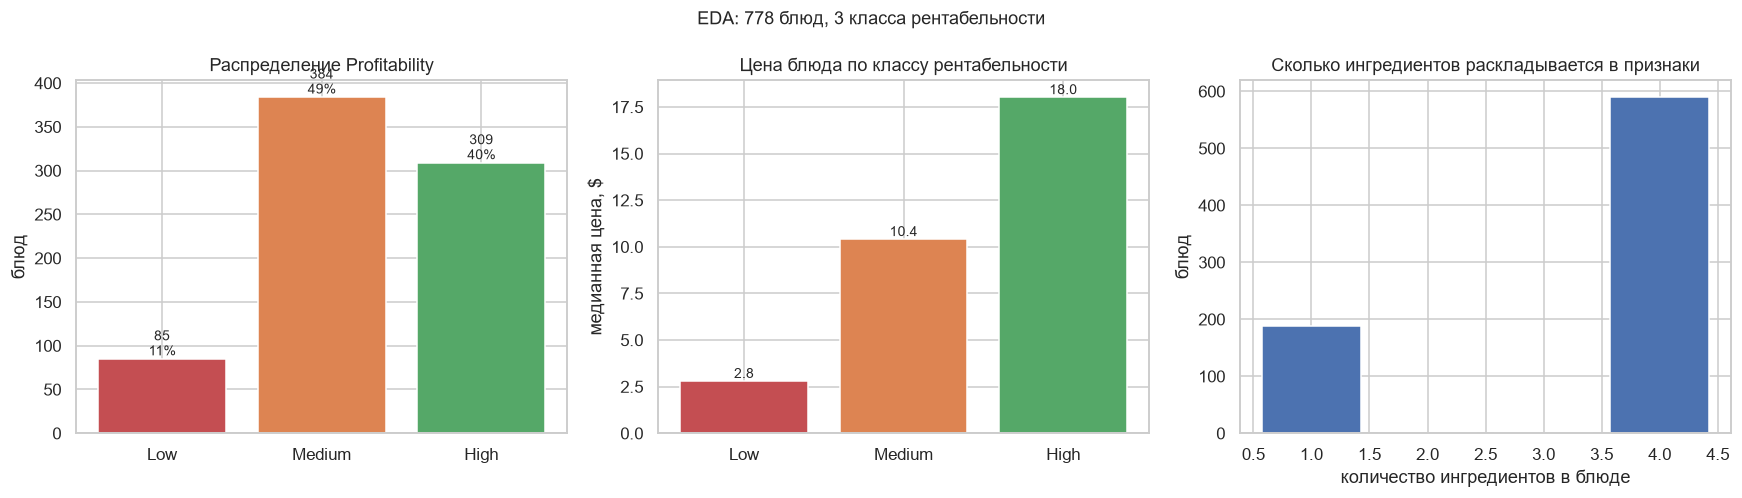

In [19]:
order = ["Low", "Medium", "High"]
colors = ["#C44E52", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

vc = train_raw["Profitability"].value_counts().reindex(order)
axes[0].bar(order, vc.values, color=colors, edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 4, f"{v}\n{v / len(train_raw):.0%}", ha="center", fontsize=9)
axes[0].set_ylabel("блюд")
axes[0].set_title("Распределение Profitability")

grp = train_raw.groupby("Profitability")["Price"].median().reindex(order)
axes[1].bar(order, grp.values, color=colors, edgecolor="white")
for i, v in enumerate(grp.values):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
axes[1].set_ylabel("медианная цена, $")
axes[1].set_title("Цена блюда по классу рентабельности")

n_ing = train_raw["Ingredients"].str.count(",") + 1
axes[2].hist(n_ing, bins=np.arange(0.5, n_ing.max() + 1.5, 1),
             color="#4C72B0", edgecolor="white", rwidth=0.85)
axes[2].set_xlabel("количество ингредиентов в блюде")
axes[2].set_ylabel("блюд")
axes[2].set_title("Сколько ингредиентов раскладывается в признаки")

fig.suptitle(f"EDA: {len(train_raw)} блюд, 3 класса рентабельности", fontsize=12)
fig.tight_layout()
plt.show()

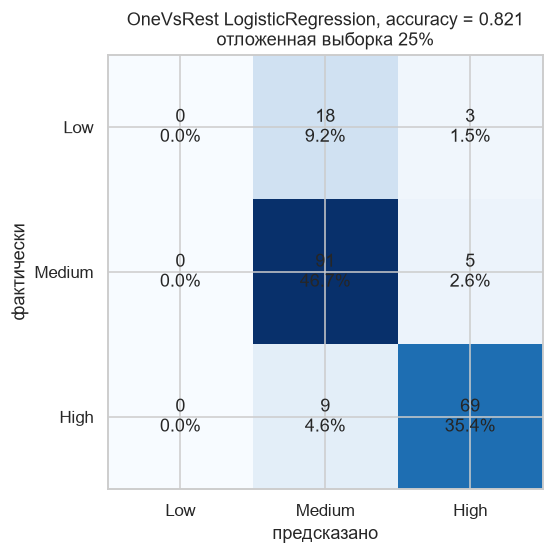

In [20]:
cm = confusion_matrix(y_va, pred_val)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.imshow(cm, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i, j]}\n{cm[i, j] / cm.sum():.1%}",
                ha="center", va="center", fontsize=12)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(order)
ax.set_yticklabels(order)
ax.set_xlabel("предсказано")
ax.set_ylabel("фактически")
ax.set_title(f"OneVsRest LogisticRegression, accuracy = {(pred_val == y_va).mean():.3f}\n"
             "отложенная выборка 25%")
fig.tight_layout()
plt.show()

### Что из этого следует

Класс `Low` не распознаётся вообще: полнота 0.00, все объекты этого класса
ушли в Medium или High. Accuracy около 0.82 при macro F1 около 0.58, то есть
цифра из ТЗ проходится, а на третьем классе модель не работает.

Причина в том, что `Low` это 85 блюд из 778, а One-vs-Rest без `class_weight`
оптимизирует суммарную ошибку и редкий класс просто игнорирует.

Что бы допилил:

* `class_weight="balanced"` или сбалансированный сэмплинг, иначе `Low`
  так и останется нераспознанным;
* перейти на macro F1, accuracy на трёх классах с таким дисбалансом
  ничего не показывает;
* выкинуть `MenuItem`, `RestaurantID` и `MenuCategory` из признаков, иначе
  модель выучивает «блюдо X всегда High» вместо связи с составом;
* в `categorial` нет обработки пропусков, при появлении нового блюда в тесте
  набор бинарных колонок разойдётся с обучением.

**Результат:** Accuracy = 0.8154

## Картинки для readme

Распределение классов и разложение `Ingredients` в бинарные признаки,
плюс матрица ошибок на удержанной части. Картинки нужны для `README.md`,
на `result.csv` не влияют, код стоит в конце ноутбука.

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = "images"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=110, bbox_inches="tight")
    plt.close(fig)
    print("сохранено:", path)

train = pd.read_csv("train.csv")


In [22]:
# Классы рентабельности: Medium 384, High 309, Low 85. Низкий класс
# занимает 11% и именно он не распознаётся дальше.
# Вторая панель - сколько ингредиентов разворачивается в бинарные признаки.
order = ["Low", "Medium", "High"]
colors = ["#C44E52", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

vc = train["Profitability"].value_counts().reindex(order)
axes[0].bar(order, vc.values, color=colors, edgecolor="white")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 4, f"{v}\n{v / len(train):.0%}", ha="center", fontsize=9)
axes[0].set_ylabel("блюд")
axes[0].set_title("Распределение Profitability")

grp = train.groupby("Profitability")["Price"].median().reindex(order)
axes[1].bar(order, grp.values, color=colors, edgecolor="white")
for i, v in enumerate(grp.values):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
axes[1].set_ylabel("медианная цена, $")
axes[1].set_title("Цена блюда по классу рентабельности")

n_ing = train["Ingredients"].str.count(",") + 1
axes[2].hist(n_ing, bins=np.arange(0.5, n_ing.max() + 1.5, 1),
             color="#4C72B0", edgecolor="white", rwidth=0.85)
axes[2].set_xlabel("количество ингредиентов в блюде")
axes[2].set_ylabel("блюд")
axes[2].set_title("Сколько ингредиентов раскладывается в признаки")

fig.suptitle(f"EDA: {len(train)} блюд, 3 класса рентабельности", fontsize=12)
fig.tight_layout()
save_fig(fig, "eda_profitability.png")

сохранено: images\eda_profitability.png


In [23]:
# Та же матрица ошибок, что в блоке проверки, но с подписями для readme.
cm = confusion_matrix(y_va, pred_val)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.imshow(cm, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i, j]}\n{cm[i, j] / cm.sum():.1%}",
                ha="center", va="center", fontsize=12)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(order)
ax.set_yticklabels(order)
ax.set_xlabel("предсказано")
ax.set_ylabel("фактически")
ax.set_title(f"OneVsRest LogisticRegression, accuracy = {(pred_val == y_va).mean():.3f}\n"
             "удержанная выборка 25%")
fig.tight_layout()
save_fig(fig, "confusion_matrix.png")

сохранено: images\confusion_matrix.png


### Что видно на матрице

Первый столбец целиком нули: ни один объект класса `Low` модель не
распознала, все 21 ушли в Medium или High. При этом accuracy 0.82,
потому что два других класса предсказываются хорошо.

Это ровно тот случай, когда accuracy врёт. Macro F1 около 0.58, и разрыв
с accuracy показывает, что треть данных модель не различает вообще.